Post-processing eccentricity posterior using [gw_eccentricity](https://github.com/vijayvarma392/gw_eccentricity)<br>
In this example, we use a parameter estimation result file from [Bilby](https://git.ligo.org/lscsoft/bilby)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Path to PE result file

In [2]:
result_file = "/mnt/c/AKASH/git-repositories/gitlab@icts/ESIGMA-GWTC-PE/alice/prod_injections/HM-debug/ESIGMAHM-ESIGMAHM/outdir_ESIGMAHM_ESIGMAHM_inj/result/ESIGMAHM-ESIGMAHM-inj_data0_1126259462-4_analysis_H1L1V1_merge_result.hdf5"
# injection_file = "/Users/arif/Desktop/injection_params_seob.dat"

# Postprocess the posterior file

For postprocessing Bilby result, we will use the derived class `PostProcessForBilby`

In [3]:
from gw_eccentricity.postprocess import PostProcessForBilby

/home/akash-x16/miniconda3/envs/esigma-igwn39/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Create a datadict generator

In addition to the posterior result file, we need to provide a
`data_dict_generator` function which given a `params` dict, returns a data_dict
that will be used to measure eccentricity using
`gw_eccentricity.measure_eccentricity`

The intrinsic parameters (reference frequency, masses, spins, eccentricity and
mean anomaly) should match the parameters used to generate the waveforms when
using bilby

In this example, we use a posterior generated with `ESIGMAHM` waveform
model. We will use `esigma_data_dict_generator` from `esigmahm.py` as the `data_dict_generator`.

In [4]:
from esigmahm import esigma_data_dict_generator

No version information file '.version' found


## Instantiate PostProcessForBilby class

Now we use the posterior result file and the `data_dict_generator` to instantiate an instance of  `PostProcessForBilby` class

In [5]:
# If  None, it works with the full posterior. We can work with only the relevant columns
parameter_columns = ["mass_1", "mass_2", 
                     "spin_1z", "spin_2z", 
                     "minimum_frequency", "reference_frequency",
                     "eccentricity", 
                     # "mean_per_ano",
                    "mean_anomaly",
                     "luminosity_distance",
                     "waveform_approximant"]

parameter_columns = None

egwBilby = PostProcessForBilby(result_file, 
                               data_dict_generator=esigma_data_dict_generator,
                               data_dict_generator_extra_kwargs={
                                   "delta_t": 1./2048.,
                                   "f_lower": 9.5 # For backward evolution; the analyzed samples had minimum_frequency=10.
                               }, 
                              # injection_file=injection_file, # FIXME: Injection samples are present in the results file itself,
                                                               # but the postprocessing module currently expects a separate injection file
                              parameter_columns=parameter_columns)

/home/akash-x16/miniconda3/envs/esigma-igwn39/lib/python3.9/site-packages/cupy/_environment.py:541: UserWarning: 
--------------------------------------------------------------------------------

  CuPy may not function correctly because multiple CuPy packages are installed
  in your environment:

    cupy, cupy-cuda12x

  Follow these steps to resolve this issue:

    1. For all packages listed above, run the following command to remove all
       existing CuPy installations:

         $ pip uninstall <package_name>

      If you previously installed CuPy via conda, also run the following:

         $ conda uninstall cupy

    2. Install the appropriate CuPy package.
       Refer to the Installation Guide for detailed instructions.

         https://docs.cupy.dev/en/stable/install.html

--------------------------------------------------------------------------------

  warnings.warn(f'''
/home/akash-x16/miniconda3/envs/esigma-igwn39/lib/python3.9/site-packages/pykerr/qnm.py:2: UserWar

lal.MSUN_SI != Msun
__name__ = gwsurrogate.new.spline_evaluation
__package__= gwsurrogate.new


## Looking at the original posteriors

We can also load the injection in case we are doing an injection using model waveform.

In [15]:
# injection = egwBilby.get_injection_params()

In [16]:
# data_dict = egwBilby.get_injection_data_dict()

In [17]:
# plt.plot(data_dict["t"], np.abs(data_dict["hlm"][(2, 2)]))

Finally plot the model posterior

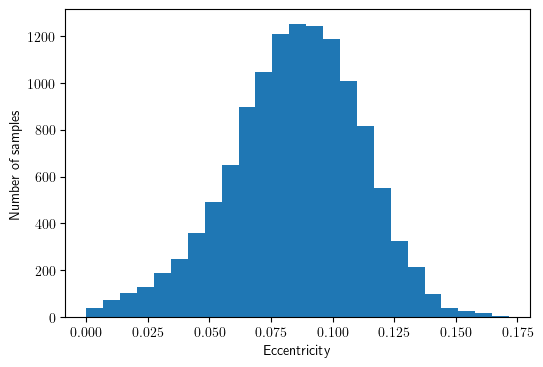

In [6]:
fig, ax = egwBilby.plot_eccentricity_posterior(**{"bins": 25})
# ax.axvline(injection["eccentricity"], c="tab:red")

In [7]:
# fig, ax = egwBilby.plot_mean_per_ano_posterior(**{"bins": 25}) # FIXME: expects "mean_per_ano" as the key in PE samples for mean anomaly
# ax.axvline(injection["mean_per_ano"], c="tab:red")

## Getting the allowed range of reference frequencies to use
Sometimes the chosen `fref`, the frequency where eccentricity and mean anomaly are to be measured could be outside the range where `egw` can be measured. Running the following code will give an idea of the `fref` bounds withing which majority of the samples can be post-processed.

This will also give an idea about how much backward evolving is required to get the orbit average frequency down to the desired `fref`.

In [8]:
import random

In [9]:
# we can use a subset of the samples to save time
samples = random.sample(range(0, len(egwBilby.posterior)), k=1000)

In [10]:
# some settings to use
method = "Amplitude"
gw_eccentricity_kwargs = {"extra_kwargs": {
    "omega_gw_extrema_interpolation_method": "spline"
}}
n_jobs = 4

In [11]:
fref_bounds_result = egwBilby.get_fref_bounds(
    samples=samples,
    method=method,
    n_jobs=n_jobs,
    gw_eccentricity_kwargs=gw_eccentricity_kwargs)
print("Allowed range of reference frequencies are: ", fref_bounds_result.get_minmax_fref())

Getting fref bounds: 4it [00:00, 39.07it/s]/home/akash-x16/miniconda3/envs/esigma-igwn39/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/akash-x16/miniconda3/envs/esigma-igwn39/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/akash-x16/miniconda3/envs/esigma-igwn39/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/akash-x16/miniconda3/envs/esigma-igwn39/lib/python3.9/site-packages/pandas/core/computation/expr

Allowed range of reference frequencies are:  (9.706655402409393, 10.25591207355883)


The range of allowed reference frequencies comes from the samples where eccentricity measurement is successfull. We can get a summary of how many samples were successfully processed.

In [12]:
fref_bounds_result.get_summary()["success_percentage"]

99.9

We can also view the full result as a DataFrame

In [13]:
fref_bounds_result.to_dataframe()

,sample_index,status,fref_min,fref_max,error_message
0,10340,success,9.684116,30.766407,None
1,4802,success,9.680303,30.290093,None
2,3379,success,9.649764,31.027533,None
3,398,success,9.671662,23.552955,None
4,9162,success,9.597745,30.109816,None
...,...,...,...,...,...
995,1729,success,9.660682,30.278267,None
996,11925,success,9.670620,30.617088,None
997,9186,success,9.609996,30.433179,None
998,5493,success,9.659753,30.261840,None


## Postprocessing

We can postprocess a subset of the smaples or all the samples using the following method

In [16]:
import time

In [17]:
fref = 10.
t_start = time.perf_counter()
samples = random.sample(range(0, len(egwBilby.posterior)), k=1000)
# samples = np.arange(len(egwBilby.posterior))
egwBilby.postprocess(fref=fref, samples=samples,
                      method=method,
                      gw_eccentricity_kwargs=gw_eccentricity_kwargs,
                      n_jobs=n_jobs)
t_stop = time.perf_counter()

Postprocessing samples: 520it [00:06, 79.40it/s]/home/akash-x16/miniconda3/envs/esigma-igwn39/lib/python3.9/site-packages/gw_eccentricity/eccDefinition.py:1757: UserWarning: Nonmonotonic time derivative detected in the spline interpolant through pericenters. Using rational fit by setting 'omega_gw_extrema_interpolation_method' to 'rational_fit' may provide better result.
  debug_message(
Postprocessing samples: 1000it [00:13, 76.52it/s]


In [18]:
print(f"Took {t_stop - t_start} seconds for {len(samples)} samples on {n_jobs} cores.")

Took 13.44423303000076 seconds for 1000 samples on 4 cores.


### View the postprocessing results

In [19]:
egwBilby.postprocess_result.results[:5]

[PostProcessResult(sample_index=8664, status='success', egw=0.07089349189972605, lgw=3.3366383733528906, error_message=None),
 PostProcessResult(sample_index=11020, status='success', egw=0.12672952516474112, lgw=1.5368166748029282, error_message=None),
 PostProcessResult(sample_index=8182, status='success', egw=0.09761614239391625, lgw=5.786911057655935, error_message=None),
 PostProcessResult(sample_index=908, status='success', egw=0.11611154650775168, lgw=5.692384854273753, error_message=None),
 PostProcessResult(sample_index=1032, status='success', egw=0.04932048610305051, lgw=1.8338690116480514, error_message=None)]

View as a DataFrame

In [20]:
egwBilby.postprocess_result.to_dataframe()

,sample_index,status,egw,lgw,error_message
0,8664,success,0.070893,3.336638,None
1,11020,success,0.126730,1.536817,None
2,8182,success,0.097616,5.786911,None
3,908,success,0.116112,5.692385,None
4,1032,success,0.049320,1.833869,None
...,...,...,...,...,...
995,6646,success,0.112506,0.753809,None
996,584,success,0.107742,0.485378,None
997,7581,success,0.108183,2.739907,None
998,2910,success,0.088043,5.913459,None


Get a summary

In [21]:
egwBilby.postprocess_result.get_summary()["success_percentage"]

100.0

Measure eccentricity of the injection

In [52]:
# egw_inj, mean_ano_inj = egwBilby.get_injection_egw_and_lgw(
#     fref=fref,
#     method=method,
#     gw_eccentricity_kwargs=gw_eccentricity_kwargs,
# )

Plot the `egw` posterior

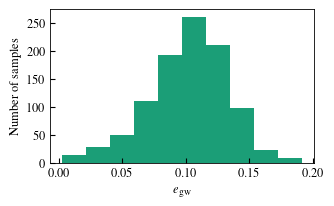

In [22]:
fig, ax = egwBilby.plot_egw_posterior(usetex=True, style="APS")
# ax.axvline(egw_inj, c="tab:red")

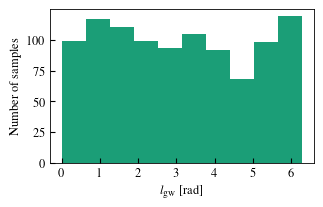

In [23]:
fig, ax = egwBilby.plot_lgw_posterior(usetex=True, style="APS")
# ax.axvline(mean_ano_inj, c="tab:red")

## compare with model posterior

Text(0, 0.5, 'Density')

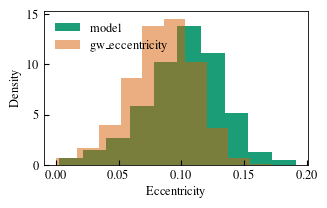

No version information file '.version' found
No version information file '.version' found
No version information file '.version' found
No version information file '.version' found


In [24]:
fig, ax = egwBilby.plot_egw_posterior(usetex=True, style="APS", **{"density": True}, label="model")
# ax.axvline(egw_inj, c="tab:red")
egwBilby.plot_eccentricity_posterior(fig=fig, ax=ax, alpha=0.5, **{"density": True}, label="gw_eccentricity")
# ax.axvline(egwBilby.get_injection_params()["eccentricity"], ls="--", c="k")
ax.legend()
ax.set_ylabel("Density")